In [1]:
import sys
print(sys.executable)

d:\AI-MLTraining\machine_learning\venv\Scripts\python.exe


In [2]:
import numpy as np 
print(f"NumPy Version: {np.__version__}")


NumPy Version: 1.26.4


In [3]:
import tensorflow as tf
print(f"tensorflow Version: {tf.__version__}")


tensorflow Version: 2.15.0


In [4]:
import tensorflow as tf
import keras

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version: {keras.__version__}")

TensorFlow Version: 2.15.0
Keras Version: 2.15.0


In [5]:
import numpy as np
import pandas as pd
import tensorflow


In [6]:
df=pd.read_csv("Churn_Modelling.csv")

In [7]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.shape

(10000, 14)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [10]:
df.duplicated().sum()

0

In [11]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [12]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [13]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'],inplace=True)

In [14]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
print(df.columns)

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')


In [16]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True, dtype=int)

In [17]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [18]:
X = df.drop(columns=['Exited'])
y = df['Exited']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [19]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1


In [20]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [22]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [24]:
model = Sequential()#we would make sequential type  models 
#making and obj of sequential data 

In [25]:
"""model.add(Dense(3,activation='sigmoid',input_dim = 11))#nodes of hidden layer,no of input=11
model.add(Dense(1,activation='sigmoid'))#output layer"""
model.add(Dense(11,activation='relu',input_dim = 11))
model.add(Dense(11,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [26]:
model.summary()#gives summary to your moidel 

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 11)                132       
                                                                 
 dense_1 (Dense)             (None, 11)                132       
                                                                 
 dense_2 (Dense)             (None, 1)                 12        
                                                                 
Total params: 276 (1.08 KB)
Trainable params: 276 (1.08 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [27]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])#optimizer is to reduce weight
#metrics accuracy tells how to measue performance

In [28]:
history=model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)#validationsplit 20 % of the data will be used for testing

Epoch 1/100


200/200 [==============================] - 2s 4ms/step - loss: 0.5112 - accuracy: 0.7956 - val_loss: 0.4696 - val_accuracy: 0.8050
Epoch 2/100
200/200 [==============================] - 1s 3ms/step - loss: 0.4555 - accuracy: 0.8087 - val_loss: 0.4403 - val_accuracy: 0.8144
Epoch 3/100
200/200 [==============================] - 1s 3ms/step - loss: 0.4369 - accuracy: 0.8164 - val_loss: 0.4301 - val_accuracy: 0.8150
Epoch 4/100
200/200 [==============================] - 1s 4ms/step - loss: 0.4293 - accuracy: 0.8206 - val_loss: 0.4255 - val_accuracy: 0.8188
Epoch 5/100
200/200 [==============================] - 1s 4ms/step - loss: 0.4233 - accuracy: 0.8242 - val_loss: 0.4186 - val_accuracy: 0.8213
Epoch 6/100
200/200 [==============================] - 1s 3ms/step - loss: 0.4181 - accuracy: 0.8263 - val_loss: 0.4130 - val_accuracy: 0.8219
Epoch 7/100
200/200 [==============================] - 1s 3ms/step - loss: 0.4130 - accuracy: 0.8278 - val_loss: 0.4081 - val_accuracy: 0.82

In [29]:
#we will fetch weights and biases for 1 st layers
model.layers[0].get_weights()

[array([[ 1.01333290e-01, -1.59726232e-01, -6.00193977e-01,
          6.65904731e-02,  1.85499370e-01, -6.64028227e-02,
          9.17181298e-02,  3.36364061e-02, -3.39885652e-02,
          3.17729205e-01, -3.57867368e-02],
        [-6.59312487e-01, -4.90261018e-01, -5.48139334e-01,
          2.96321623e-02, -1.40768781e-01, -4.47148114e-01,
          2.93276906e-01,  5.43756858e-02,  7.43405044e-01,
         -7.94149637e-01, -2.78565258e-01],
        [ 2.92833522e-02,  2.52780437e-01, -6.03347085e-02,
         -1.26881283e-02, -6.33118302e-02,  4.78905469e-01,
          2.08639298e-02, -4.68528569e-02,  2.37550363e-01,
         -5.59438586e-01, -1.02047369e-01],
        [ 8.39269310e-02, -5.87910593e-01,  2.51758099e-01,
         -1.61646307e-01,  3.86900693e-01, -7.67806411e-01,
          2.26087034e-01, -3.04775476e-01,  1.85885921e-01,
         -6.30801737e-01,  1.25947371e-02],
        [-4.60972250e-01, -4.58487198e-02, -5.26776373e-01,
         -1.37560785e+00, -2.73635387e-01, -

In [30]:
#we will fetch weights and biases for next layers
model.layers[1].get_weights()

[array([[-0.54109544,  0.30018178,  0.00386534,  0.69711673,  0.37241492,
          0.07448027, -0.54207915, -0.7570065 , -0.03797783, -1.0652279 ,
         -0.08470366],
        [ 0.7918494 , -0.1078441 ,  0.18371923, -0.28428108,  0.5157904 ,
          0.16064918,  0.04620108,  0.46819052, -0.14186385, -0.5045322 ,
          0.6069832 ],
        [-0.17835411,  0.3208384 ,  0.03908178, -0.08167633,  0.32757926,
         -0.08290102,  0.2523296 ,  0.3400301 ,  0.49857116, -0.23686916,
         -0.68591547],
        [ 0.6762455 , -0.2287522 , -0.8974923 , -0.27331755, -0.23125277,
         -0.21569498, -0.9139532 ,  0.49572247,  0.5540052 ,  0.7612012 ,
         -0.1732908 ],
        [ 0.05264102, -0.27123377,  0.2205843 ,  0.03511016, -0.03640549,
         -0.6698507 ,  0.18817355,  0.06295248,  0.5013134 ,  0.28082037,
         -0.5238306 ],
        [-0.00662883, -0.02814833, -0.02379559,  0.15288113, -0.2861947 ,
         -0.6093624 ,  0.6650514 ,  0.1235581 ,  0.32101148,  0.1908388

In [31]:
y_log=model.predict(X_test_scaled)

63/63 [==============================] - 0s 2ms/step


In [32]:
y_pred=np.where(y_log>0.5,1,0)#if greater than 0.5 return 1 else 0

In [33]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.859

In [34]:
import matplotlib.pyplot as plt 

In [35]:
history.history

{'loss': [0.5111671686172485,
  0.45552539825439453,
  0.43689465522766113,
  0.4292627274990082,
  0.42329704761505127,
  0.4180595278739929,
  0.4129602015018463,
  0.4084462821483612,
  0.40424662828445435,
  0.4002349376678467,
  0.3961160182952881,
  0.392295241355896,
  0.38921695947647095,
  0.38598278164863586,
  0.3833545744419098,
  0.3804379403591156,
  0.37770503759384155,
  0.37520813941955566,
  0.3727613687515259,
  0.37053385376930237,
  0.36856406927108765,
  0.3665154278278351,
  0.36493998765945435,
  0.3628741204738617,
  0.3610157072544098,
  0.35911422967910767,
  0.3576829135417938,
  0.3558802008628845,
  0.3549448847770691,
  0.3530528247356415,
  0.3518144190311432,
  0.35050544142723083,
  0.34906116127967834,
  0.3483426570892334,
  0.347209095954895,
  0.3458769917488098,
  0.3454742729663849,
  0.3446356952190399,
  0.3440871834754944,
  0.34309718012809753,
  0.3416821360588074,
  0.3415951430797577,
  0.340720534324646,
  0.34020623564720154,
  0.3398075

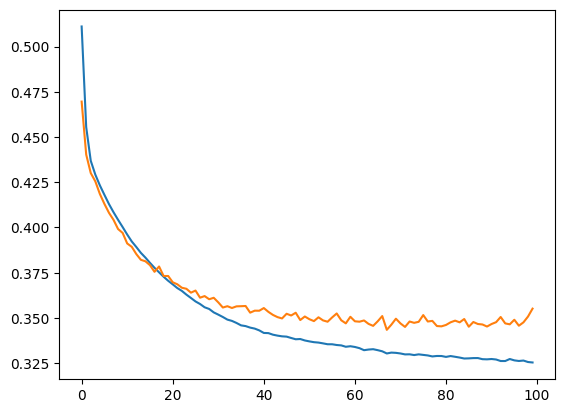

In [36]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

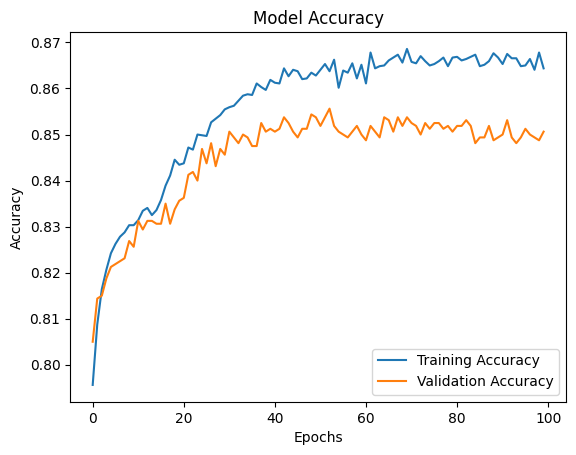

In [37]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()